In [13]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [7]:
df = pd.read_csv('clean_comments.csv').dropna(subset=['clean_comment'])
df.shape

(54153, 3)

In [12]:
def experiments_with_BoW(max_features):
  ngram_range = (1, 3)

  vectorizer = CountVectorizer(ngram_range=ngram_range, max_features=max_features)
  X_train, X_test, y_train, y_test = train_test_split(df['clean_comment'], df['category'], test_size=0.2, random_state=42, stratify=df['category'])

  X_train = vectorizer.fit_transform(X_train)
  X_test = vectorizer.transform(X_test)

  n_estimators = 200
  max_depth = 15

  model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
  model.fit(X_train, y_train)

  y_pred = model.predict(X_test)
  accuracy = accuracy_score(y_test, y_pred)
  classification_rep = classification_report(y_test, y_pred, output_dict=True)

  print(accuracy)
  print(classification_rep)

  conf_matrix = confusion_matrix(y_test, y_pred)
  plt.figure(figsize=(8, 6))
  sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
  plt.xlabel("Predicted")
  plt.ylabel("Actual")
  plt.title(f"Confusion Matrix: BoW Trigrams, max_features={max_features}")
  plt.savefig("confusion_matrix.png")
  plt.show()


0.5896962422675653
{'0': {'precision': 0.5714285714285714, 'recall': 0.001896633475580844, 'f1-score': 0.003780718336483932, 'support': 2109.0}, '1': {'precision': 0.5799773114010209, 'recall': 0.6052086416099438, 'f1-score': 0.5923244026068066, 'support': 3379.0}, '2': {'precision': 0.5944094272403398, 'recall': 0.8119034250421112, 'f1-score': 0.6863381061624871, 'support': 5343.0}, 'accuracy': 0.5896962422675653, 'macro avg': {'precision': 0.5819384366899775, 'recall': 0.4730029000425453, 'f1-score': 0.4274810757019259, 'support': 10831.0}, 'weighted avg': {'precision': 0.5854321634301581, 'recall': 0.5896962422675653, 'f1-score': 0.524101393463781, 'support': 10831.0}}


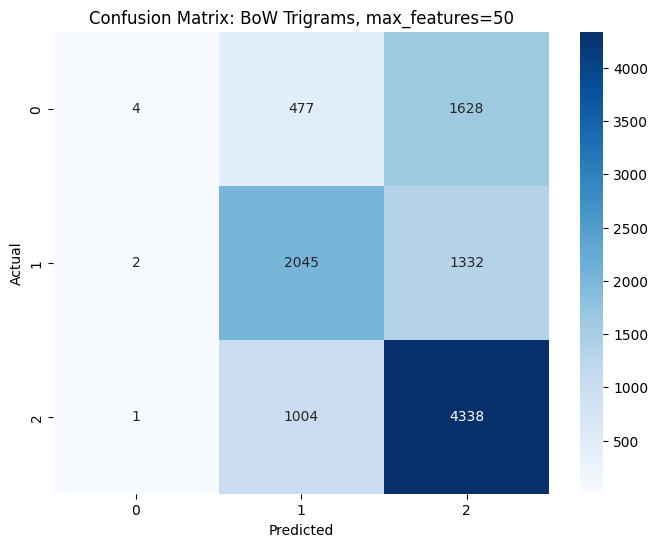

0.6158249469116425
{'0': {'precision': 0.75, 'recall': 0.008534850640113799, 'f1-score': 0.016877637130801686, 'support': 2109.0}, '1': {'precision': 0.5998439937597504, 'recall': 0.6827463746670612, 'f1-score': 0.6386159169550173, 'support': 3379.0}, '2': {'precision': 0.6241919264473496, 'recall': 0.8132135504398278, 'f1-score': 0.7062743823146944, 'support': 5343.0}, 'accuracy': 0.6158249469116425, 'macro avg': {'precision': 0.6580119734023667, 'recall': 0.5014982585823343, 'f1-score': 0.45392264546683786, 'support': 10831.0}, 'weighted avg': {'precision': 0.6410931878794558, 'recall': 0.6158249469116425, 'f1-score': 0.5509280901862503, 'support': 10831.0}}


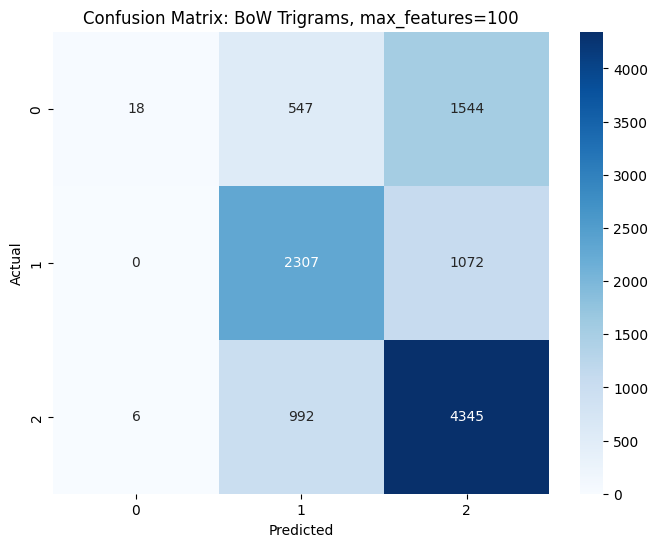

0.6226571877019665
{'0': {'precision': 0.7777777777777778, 'recall': 0.003319108582266477, 'f1-score': 0.0066100094428706326, 'support': 2109.0}, '1': {'precision': 0.6088204592901879, 'recall': 0.6904409588635692, 'f1-score': 0.647066981001248, 'support': 3379.0}, '2': {'precision': 0.6300429184549357, 'recall': 0.8242560359348681, 'f1-score': 0.7141814643639017, 'support': 5343.0}, 'accuracy': 0.6226571877019665, 'macro avg': {'precision': 0.6722137185076337, 'recall': 0.506005367793568, 'f1-score': 0.45595281826934014, 'support': 10831.0}, 'weighted avg': {'precision': 0.6521888079198226, 'recall': 0.6226571877019665, 'f1-score': 0.5554659221507301, 'support': 10831.0}}


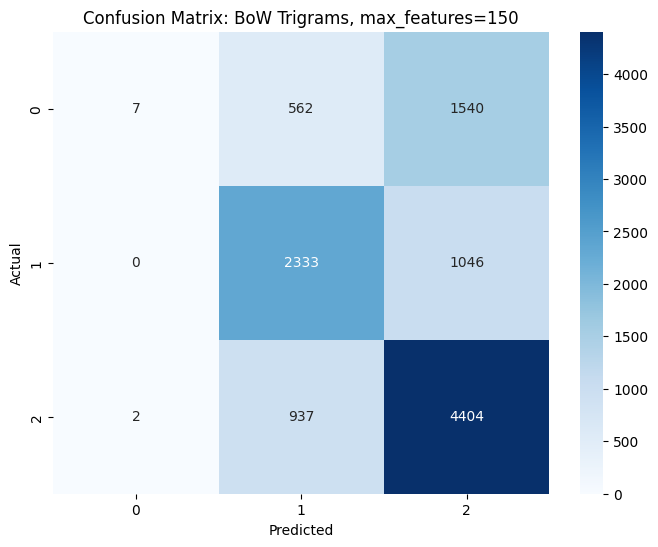

0.625980980518881
{'0': {'precision': 0.75, 'recall': 0.001422475106685633, 'f1-score': 0.002839564600094652, 'support': 2109.0}, '1': {'precision': 0.6167505963424331, 'recall': 0.6886652855874519, 'f1-score': 0.6507270693512305, 'support': 3379.0}, '2': {'precision': 0.6308477459597391, 'recall': 0.8328654314055773, 'f1-score': 0.7179156247479229, 'support': 5343.0}, 'accuracy': 0.625980980518881, 'macro avg': {'precision': 0.6658661141007242, 'recall': 0.5076510640332382, 'f1-score': 0.4571607528997494, 'support': 10831.0}, 'weighted avg': {'precision': 0.6496509806762042, 'recall': 0.625980980518881, 'f1-score': 0.5577156857268544, 'support': 10831.0}}


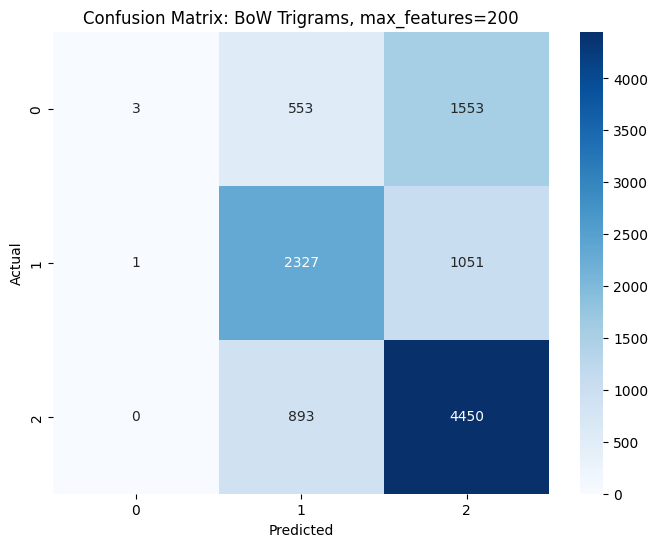

0.6371526174868433
{'0': {'precision': 0.8662790697674418, 'recall': 0.07064959696538643, 'f1-score': 0.13064445418676018, 'support': 2109.0}, '1': {'precision': 0.6330275229357798, 'recall': 0.6738680082864753, 'f1-score': 0.6528096330275229, 'support': 3379.0}, '2': {'precision': 0.6336731804021524, 'recall': 0.8375444506831368, 'f1-score': 0.7214832728738412, 'support': 5343.0}, 'accuracy': 0.6371526174868433, 'macro avg': {'precision': 0.7109932577017913, 'recall': 0.5273540186449995, 'f1-score': 0.5016457866960414, 'support': 10831.0}, 'weighted avg': {'precision': 0.678764505680753, 'recall': 0.6371526174868433, 'f1-score': 0.5850113591399511, 'support': 10831.0}}


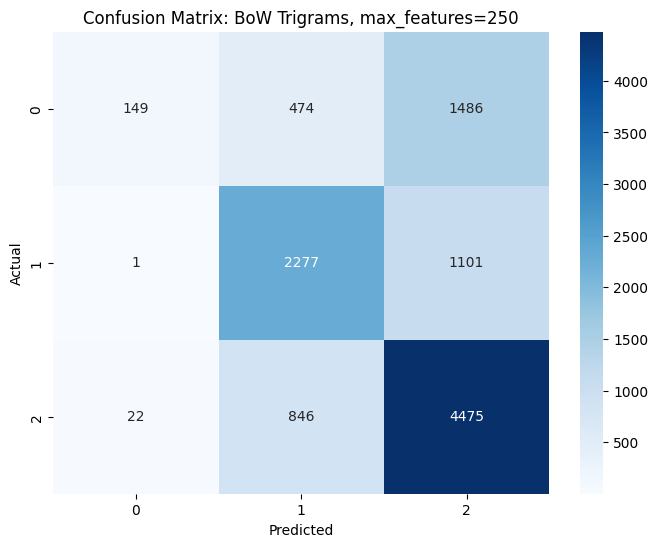

0.6416766688209768
{'0': {'precision': 0.8872180451127819, 'recall': 0.0559506875296349, 'f1-score': 0.10526315789473684, 'support': 2109.0}, '1': {'precision': 0.636888400219901, 'recall': 0.6857058301272566, 'f1-score': 0.6603961807040045, 'support': 3379.0}, '2': {'precision': 0.6395184135977338, 'recall': 0.8450308815272319, 'f1-score': 0.7280496654035314, 'support': 5343.0}, 'accuracy': 0.6416766688209768, 'macro avg': {'precision': 0.7212082863101389, 'recall': 0.5288957997280411, 'f1-score': 0.4979030013340909, 'support': 10831.0}, 'weighted avg': {'precision': 0.6869297059679249, 'recall': 0.6416766688209768, 'f1-score': 0.5856751968285385, 'support': 10831.0}}


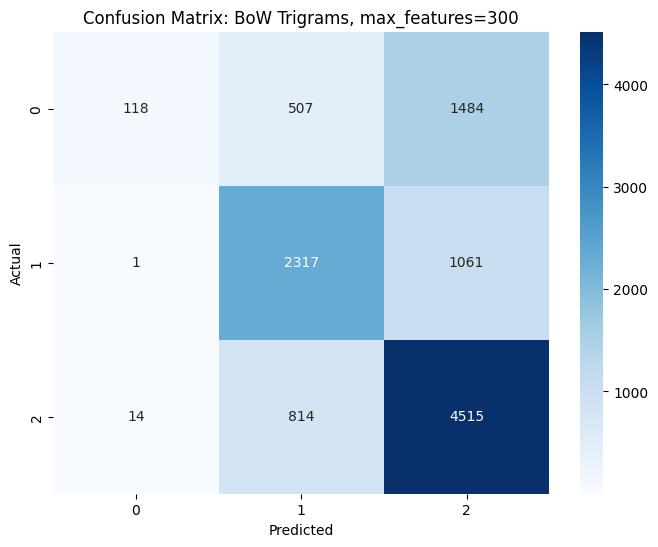

0.6446311513249008
{'0': {'precision': 0.8938547486033519, 'recall': 0.07586533902323377, 'f1-score': 0.13986013986013987, 'support': 2109.0}, '1': {'precision': 0.6393989983305509, 'recall': 0.6800828647528855, 'f1-score': 0.6591137243654094, 'support': 3379.0}, '2': {'precision': 0.6409747803910456, 'recall': 0.8467153284671532, 'f1-score': 0.729618579146843, 'support': 5343.0}, 'accuracy': 0.6446311513249008, 'macro avg': {'precision': 0.7247428424416494, 'recall': 0.5342211774144242, 'f1-score': 0.5095308144574641, 'support': 10831.0}, 'weighted avg': {'precision': 0.6897236757264109, 'recall': 0.6446311513249008, 'f1-score': 0.5927857425886193, 'support': 10831.0}}


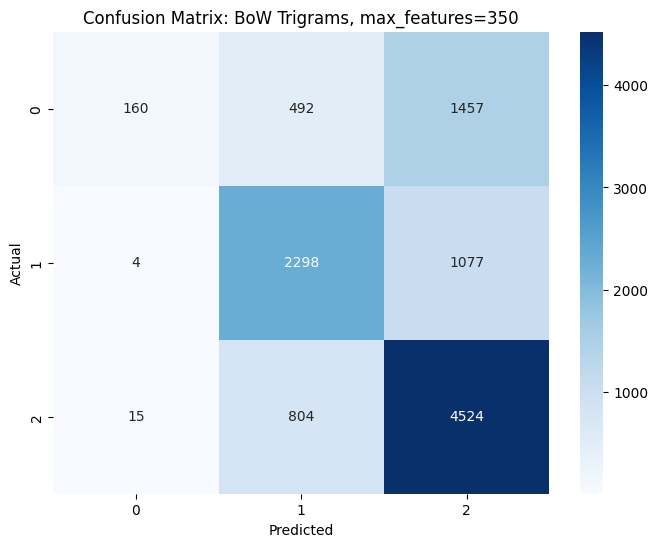

0.6502631335980057
{'0': {'precision': 0.9157303370786517, 'recall': 0.07728781412991939, 'f1-score': 0.1425448185395715, 'support': 2109.0}, '1': {'precision': 0.6487777465580219, 'recall': 0.6833382657591003, 'f1-score': 0.6656096857884116, 'support': 3379.0}, '2': {'precision': 0.6443473357767127, 'recall': 0.855511884708965, 'f1-score': 0.7350647262201495, 'support': 5343.0}, 'accuracy': 0.6502631335980057, 'macro avg': {'precision': 0.7362851398044622, 'recall': 0.538712654865995, 'f1-score': 0.5144064101827109, 'support': 10831.0}, 'weighted avg': {'precision': 0.6985729020010533, 'recall': 0.6502631335980057, 'f1-score': 0.5980216953903849, 'support': 10831.0}}


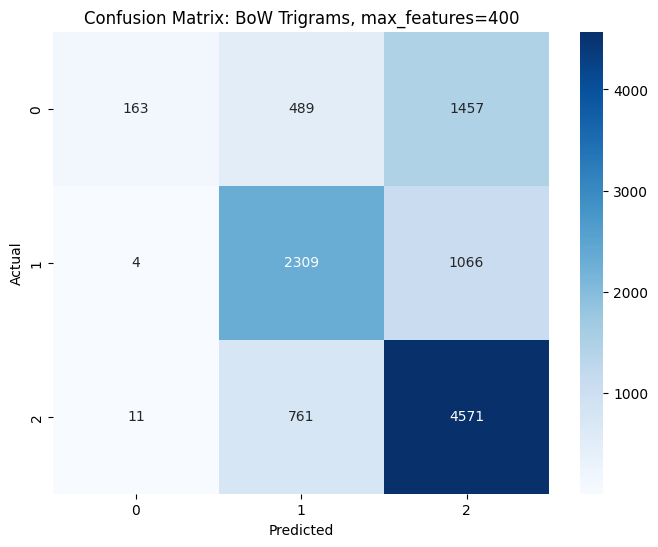

0.6474009786723294
{'0': {'precision': 0.9119496855345912, 'recall': 0.0687529634898056, 'f1-score': 0.12786596119929453, 'support': 2109.0}, '1': {'precision': 0.6466930469191634, 'recall': 0.6771234092926901, 'f1-score': 0.6615584791094405, 'support': 3379.0}, '2': {'precision': 0.6418559013176338, 'recall': 0.857009170877784, 'f1-score': 0.733990542598381, 'support': 5343.0}, 'accuracy': 0.6474009786723294, 'macro avg': {'precision': 0.7334995445904627, 'recall': 0.5342951812200932, 'f1-score': 0.507804994302372, 'support': 10831.0}, 'weighted avg': {'precision': 0.695957323707176, 'recall': 0.6474009786723294, 'f1-score': 0.5933696687455694, 'support': 10831.0}}


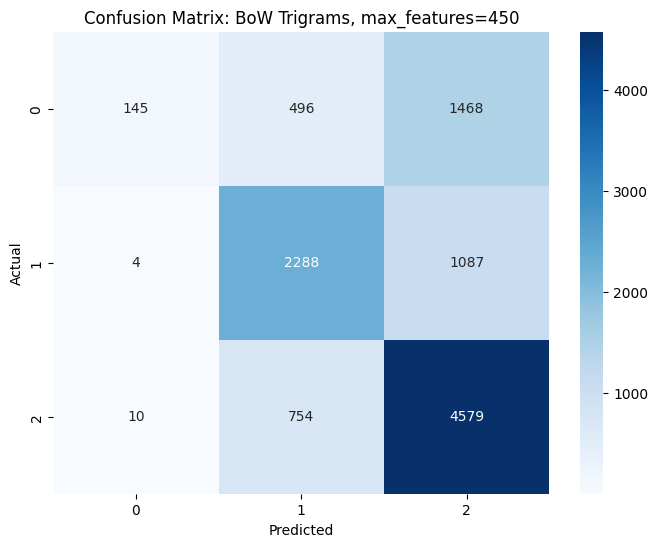

0.6427845997599483
{'0': {'precision': 0.9139072847682119, 'recall': 0.06543385490753911, 'f1-score': 0.12212389380530973, 'support': 2109.0}, '1': {'precision': 0.6484443152079092, 'recall': 0.6599585676235573, 'f1-score': 0.6541507773540628, 'support': 3379.0}, '2': {'precision': 0.6344427565253418, 'recall': 0.8598165824443197, 'f1-score': 0.7301335028607756, 'support': 5343.0}, 'accuracy': 0.6427845997599483, 'macro avg': {'precision': 0.7322647855004877, 'recall': 0.528403001658472, 'f1-score': 0.502136058006716, 'support': 10831.0}, 'weighted avg': {'precision': 0.6932279062670653, 'recall': 0.6427845997599483, 'f1-score': 0.5880378611854769, 'support': 10831.0}}


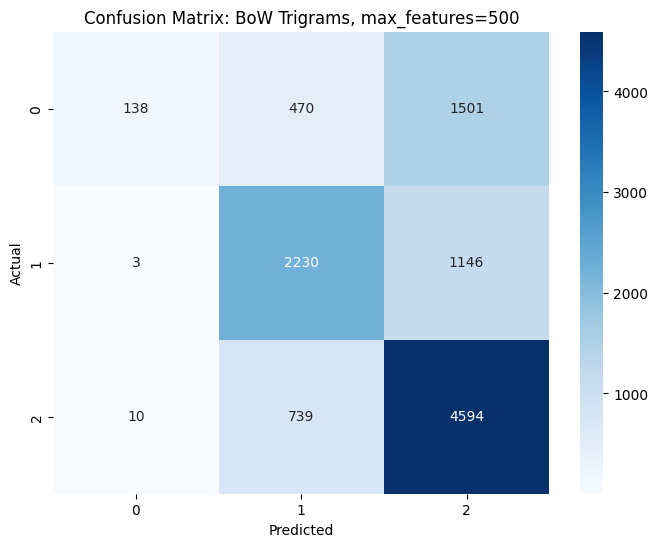

0.6434308928076816
{'0': {'precision': 0.916083916083916, 'recall': 0.06211474632527264, 'f1-score': 0.11634103019538189, 'support': 2109.0}, '1': {'precision': 0.6472278081011203, 'recall': 0.6667653151820065, 'f1-score': 0.6568513119533528, 'support': 3379.0}, '2': {'precision': 0.6361870403774108, 'recall': 0.8581321355043983, 'f1-score': 0.7306772908366533, 'support': 5343.0}, 'accuracy': 0.6434308928076816, 'macro avg': {'precision': 0.7331662548541491, 'recall': 0.5290040656705591, 'f1-score': 0.501289877661796, 'support': 10831.0}, 'weighted avg': {'precision': 0.6941326839009483, 'recall': 0.6434308928076816, 'f1-score': 0.5880225815448876, 'support': 10831.0}}


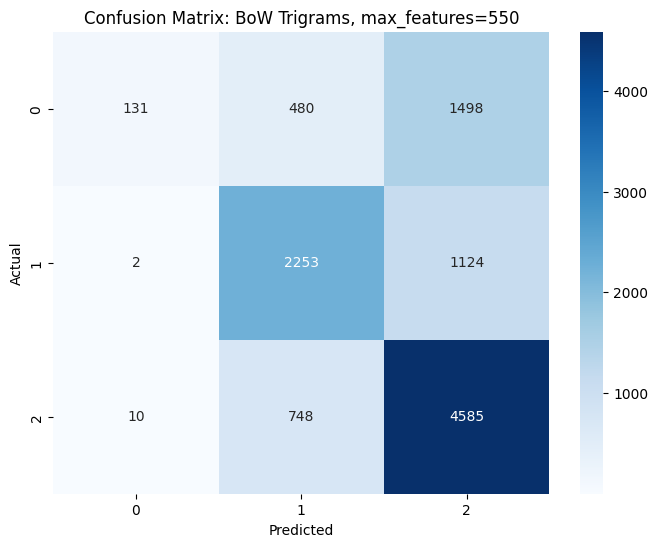

0.644077185855415
{'0': {'precision': 0.8916666666666667, 'recall': 0.05073494547178758, 'f1-score': 0.09600717810677434, 'support': 2109.0}, '1': {'precision': 0.6532374100719425, 'recall': 0.6717963894643386, 'f1-score': 0.6623869273416982, 'support': 3379.0}, '2': {'precision': 0.6355721393034826, 'recall': 0.8607523862998315, 'f1-score': 0.7312186978297162, 'support': 5343.0}, 'accuracy': 0.644077185855415, 'macro avg': {'precision': 0.7268254053473638, 'recall': 0.5277612404119859, 'f1-score': 0.4965376010927296, 'support': 10831.0}, 'weighted avg': {'precision': 0.6909496952203491, 'recall': 0.644077185855415, 'f1-score': 0.5860572494339358, 'support': 10831.0}}


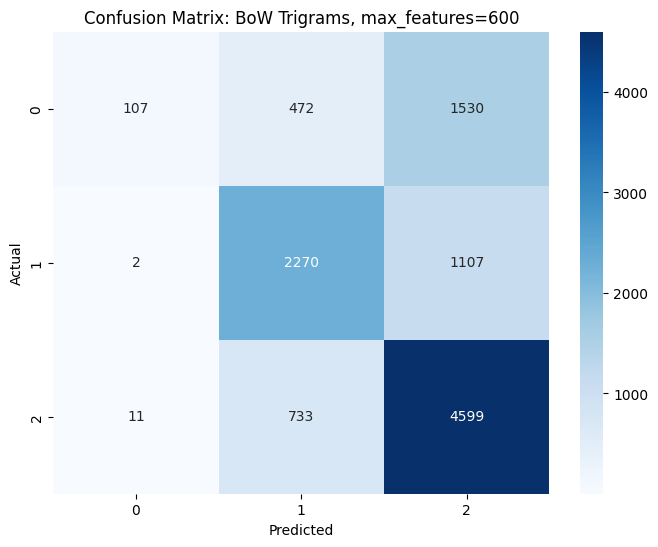

0.6430615824946911
{'0': {'precision': 0.9349593495934959, 'recall': 0.054528212422949265, 'f1-score': 0.10304659498207885, 'support': 2109.0}, '1': {'precision': 0.6528224627083943, 'recall': 0.6605504587155964, 'f1-score': 0.6566637246248896, 'support': 3379.0}, '2': {'precision': 0.6335574152833036, 'recall': 0.8643084409507767, 'f1-score': 0.7311589613679544, 'support': 5343.0}, 'accuracy': 0.6430615824946911, 'macro avg': {'precision': 0.7404464091950645, 'recall': 0.5264623706964408, 'f1-score': 0.49695642699164094, 'support': 10831.0}, 'weighted avg': {'precision': 0.6982562680863298, 'recall': 0.6430615824946911, 'f1-score': 0.5856129927904798, 'support': 10831.0}}


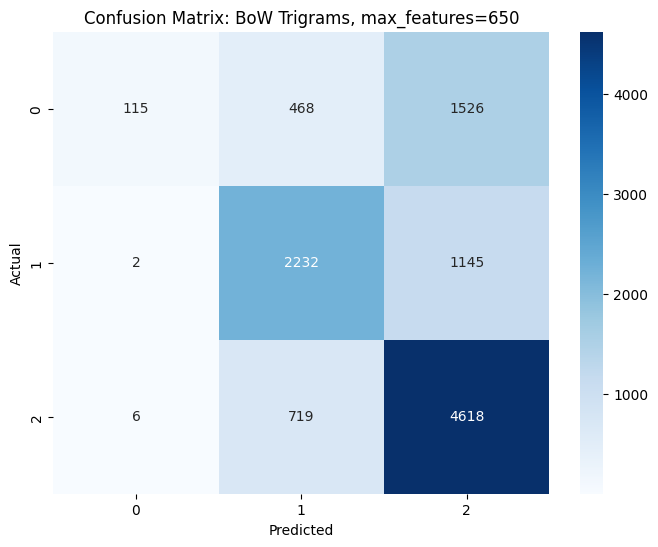

0.6419536515557197
{'0': {'precision': 0.9206349206349206, 'recall': 0.055002370791844474, 'f1-score': 0.10380313199105146, 'support': 2109.0}, '1': {'precision': 0.6494486360998258, 'recall': 0.6623261319917135, 'f1-score': 0.6558241758241758, 'support': 3379.0}, '2': {'precision': 0.6335583413693346, 'recall': 0.8607523862998315, 'f1-score': 0.7298841453737502, 'support': 5343.0}, 'accuracy': 0.6419536515557197, 'macro avg': {'precision': 0.734547299368027, 'recall': 0.5260269630277965, 'f1-score': 0.49650381772965924, 'support': 10831.0}, 'weighted avg': {'precision': 0.6944149392426104, 'recall': 0.6419536515557197, 'f1-score': 0.5848695119758993, 'support': 10831.0}}


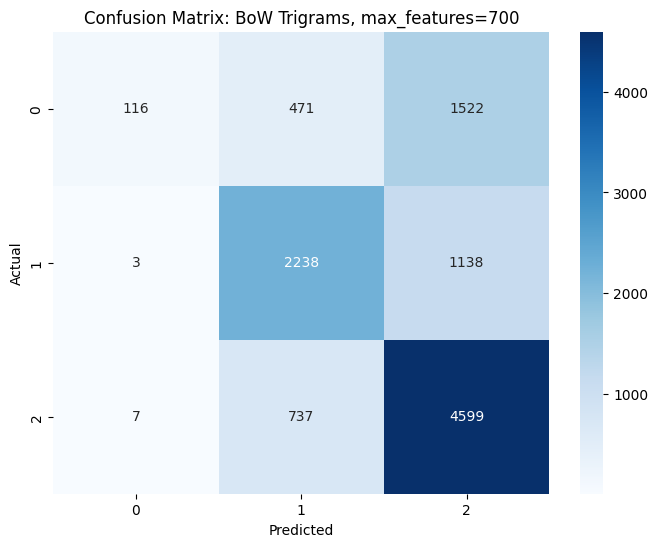

0.6416766688209768
{'0': {'precision': 0.9310344827586207, 'recall': 0.051209103840682786, 'f1-score': 0.09707865168539326, 'support': 2109.0}, '1': {'precision': 0.6521229868228404, 'recall': 0.6590707309854986, 'f1-score': 0.655578451574919, 'support': 3379.0}, '2': {'precision': 0.6321917808219178, 'recall': 0.8637469586374696, 'f1-score': 0.730048248042395, 'support': 5343.0}, 'accuracy': 0.6416766688209768, 'macro avg': {'precision': 0.7384497501344597, 'recall': 0.5246755978212171, 'f1-score': 0.49423511710090234, 'support': 10831.0}, 'weighted avg': {'precision': 0.6966001275545948, 'recall': 0.6416766688209768, 'f1-score': 0.5835644218970235, 'support': 10831.0}}


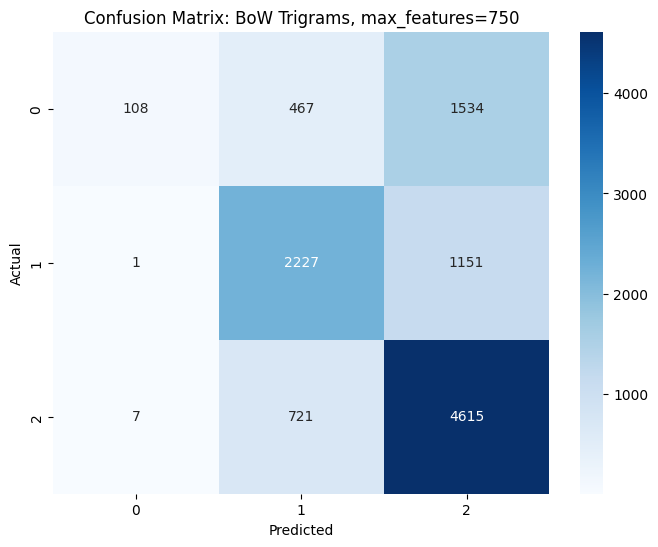

0.6389991690517958
{'0': {'precision': 0.9318181818181818, 'recall': 0.0388809862494073, 'f1-score': 0.07464724624487938, 'support': 2109.0}, '1': {'precision': 0.6517778430796356, 'recall': 0.6564072210713229, 'f1-score': 0.6540843409023887, 'support': 3379.0}, '2': {'precision': 0.6295640326975477, 'recall': 0.8648699232640839, 'f1-score': 0.7286919498541354, 'support': 5343.0}, 'accuracy': 0.6389991690517958, 'macro avg': {'precision': 0.7377200191984551, 'recall': 0.520052710194938, 'f1-score': 0.4858078456671345, 'support': 10831.0}, 'weighted avg': {'precision': 0.6953487677890897, 'recall': 0.6389991690517958, 'f1-score': 0.5780614087628351, 'support': 10831.0}}


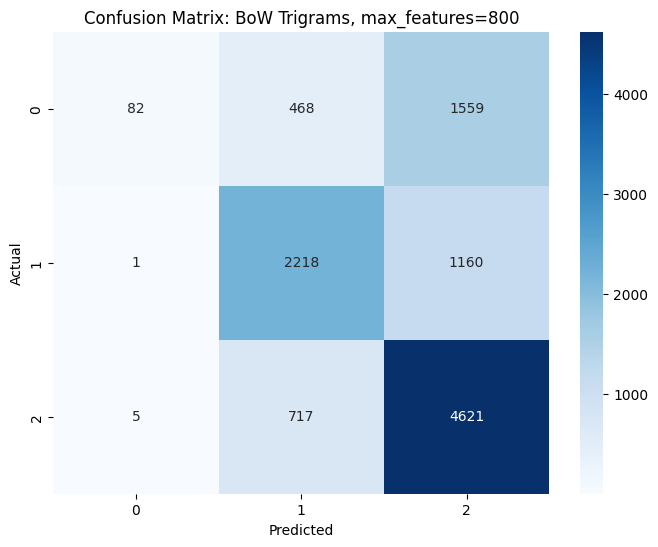

0.6420459791339673
{'0': {'precision': 0.9306930693069307, 'recall': 0.044570886676149835, 'f1-score': 0.08506787330316742, 'support': 2109.0}, '1': {'precision': 0.6570672935645019, 'recall': 0.6617342408996745, 'f1-score': 0.6593925095841935, 'support': 3379.0}, '2': {'precision': 0.6310904872389791, 'recall': 0.865431405577391, 'f1-score': 0.72991318074191, 'support': 5343.0}, 'accuracy': 0.6420459791339673, 'macro avg': {'precision': 0.739616950036804, 'recall': 0.5239121777177385, 'f1-score': 0.4914578545430903, 'support': 10831.0}, 'weighted avg': {'precision': 0.6975328724439696, 'recall': 0.6420459791339673, 'f1-score': 0.5823489575648966, 'support': 10831.0}}


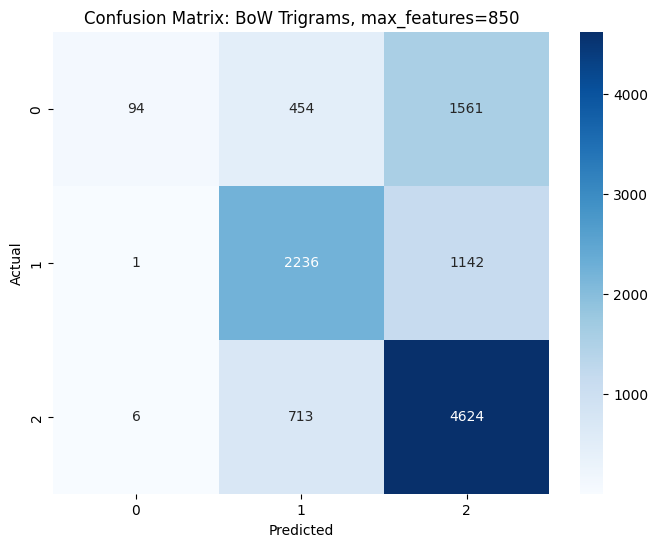

0.6386298587388053
{'0': {'precision': 0.9479166666666666, 'recall': 0.0431484115694642, 'f1-score': 0.08253968253968254, 'support': 2109.0}, '1': {'precision': 0.6530794406426659, 'recall': 0.6496004735128736, 'f1-score': 0.6513353115727003, 'support': 3379.0}, '2': {'precision': 0.6280173582858692, 'recall': 0.8667415309751076, 'f1-score': 0.7283164268302272, 'support': 5343.0}, 'accuracy': 0.6386298587388053, 'macro avg': {'precision': 0.7430044885317338, 'recall': 0.5198301386858152, 'f1-score': 0.4873971403142034, 'support': 10831.0}, 'weighted avg': {'precision': 0.6981265280447758, 'recall': 0.6386298587388053, 'f1-score': 0.578555339011564, 'support': 10831.0}}


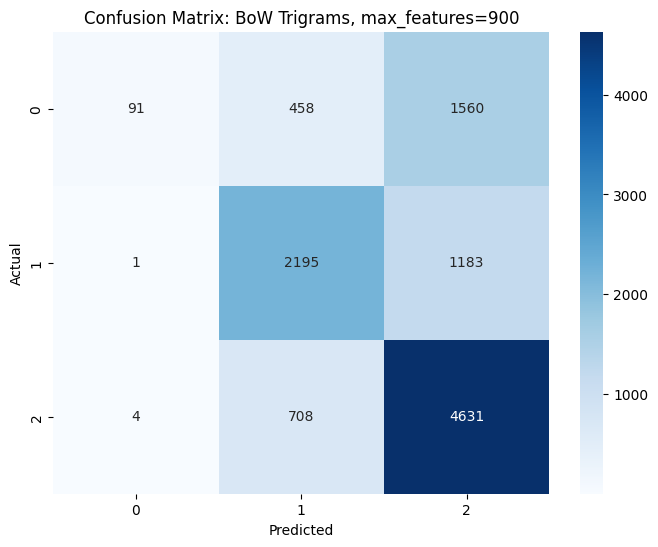

0.6419536515557197
{'0': {'precision': 0.9381443298969072, 'recall': 0.0431484115694642, 'f1-score': 0.08250226654578423, 'support': 2109.0}, '1': {'precision': 0.6603546738803727, 'recall': 0.6501923646049127, 'f1-score': 0.655234118699672, 'support': 3379.0}, '2': {'precision': 0.6298096395301742, 'recall': 0.8731049971925884, 'f1-score': 0.731764705882353, 'support': 5343.0}, 'accuracy': 0.6419536515557197, 'macro avg': {'precision': 0.7427695477691514, 'recall': 0.5221485911223218, 'f1-score': 0.489833697042603, 'support': 10831.0}, 'weighted avg': {'precision': 0.6993775033518675, 'recall': 0.6419536515557197, 'f1-score': 0.5814654409344163, 'support': 10831.0}}


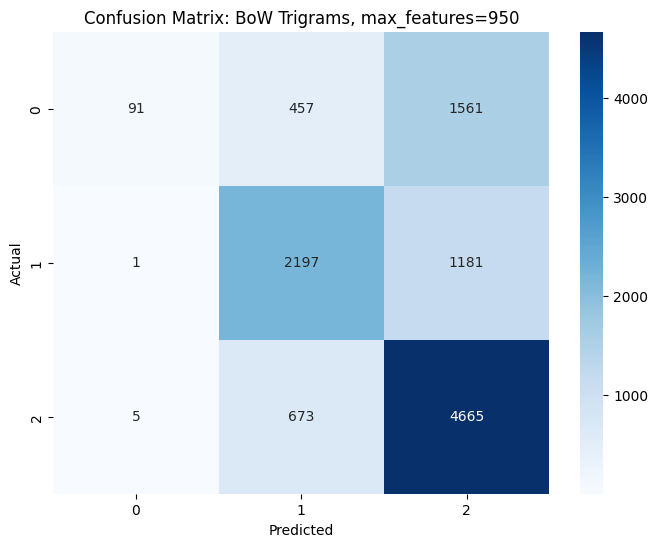

0.6404764103037577
{'0': {'precision': 0.9333333333333333, 'recall': 0.03982930298719772, 'f1-score': 0.07639836289222374, 'support': 2109.0}, '1': {'precision': 0.6604455147501506, 'recall': 0.6493045279668541, 'f1-score': 0.65482763766602, 'support': 3379.0}, '2': {'precision': 0.627982207844723, 'recall': 0.8719820325659742, 'f1-score': 0.7301363422661025, 'support': 5343.0}, 'accuracy': 0.6404764103037577, 'macro avg': {'precision': 0.7405870186427356, 'recall': 0.5203719545066753, 'f1-score': 0.4871207809414488, 'support': 10831.0}, 'weighted avg': {'precision': 0.6975675681705396, 'recall': 0.6404764103037577, 'f1-score': 0.5793468019334287, 'support': 10831.0}}


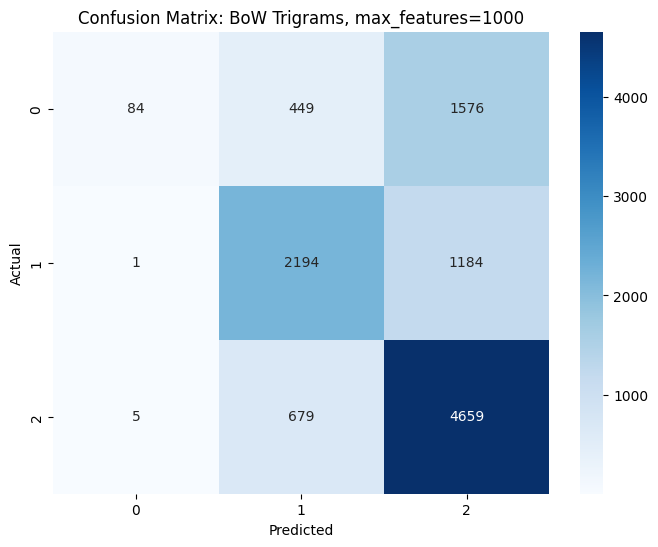

In [18]:
max_features_values = np.linspace(50, 1000, 20)

for max_features in max_features_values:
    experiments_with_BoW(int(max_features))


Compared the performance with max_feature changing, first used the range of 500 to 5000, realised the model was giving better output with lower max_features,

Ran the code again with max_featuresw from 50 to 1000, found the model performed the best with 400 max_features